# Test on B Dataset (50-100 nodes)

Poređenje aproksimacionih algoritama na SteinLib B benchmark setu (J. E. Beasley).
Poznati optimumi se koriste za poređenje.

In [13]:
%run 02_test_on_small_graphs.ipynb

In [4]:
b_files = sorted(Path('data/B').glob('*.stp'))

algorithms = [
    ('MST Heuristic', mst_heuristic, False),
    ('Mehlhorn', mehlhorn_steiner, False),
    ('SPH', sph_steiner, False),
    ('Zelikovsky', zelikovsky_steiner, False),
]

results = compare_algorithms(algorithms, b_files)

Instance      N    T | MST He  Mehlho     SPH  Zeliko
-----------------------------------------------------
B01          50    9 |     82       *   85+4%       *
B02          50   13 |     90       *   84+-7%   88+-2%
B03          50   25 |    140       *  138+-1%       *
B04          50    9 |     64   59+-8%   59+-8%   59+-8%
B05          50   13 |     64       *   62+-3%       *
B06          50   25 |    128       *  127+-1%       *
B07          75   13 |    111       *       *       *
B08          75   19 |    104       *       *       *
B09          75   38 |    224  223+-0%  223+-0%       *
B10          75   13 |     98       *   95+-3%   94+-4%
B11          75   19 |     90   93+3%   88+-2%       *
B12          75   38 |    174       *       *       *
B13         100   17 |    175       *  178+2%       *
B14         100   25 |    237       *  239+1%       *
B15         100   50 |    325  326+0%  322+-1%       *
B16         100   17 |    137       *  134+-2%       *
B17         1

## Poređenje težina

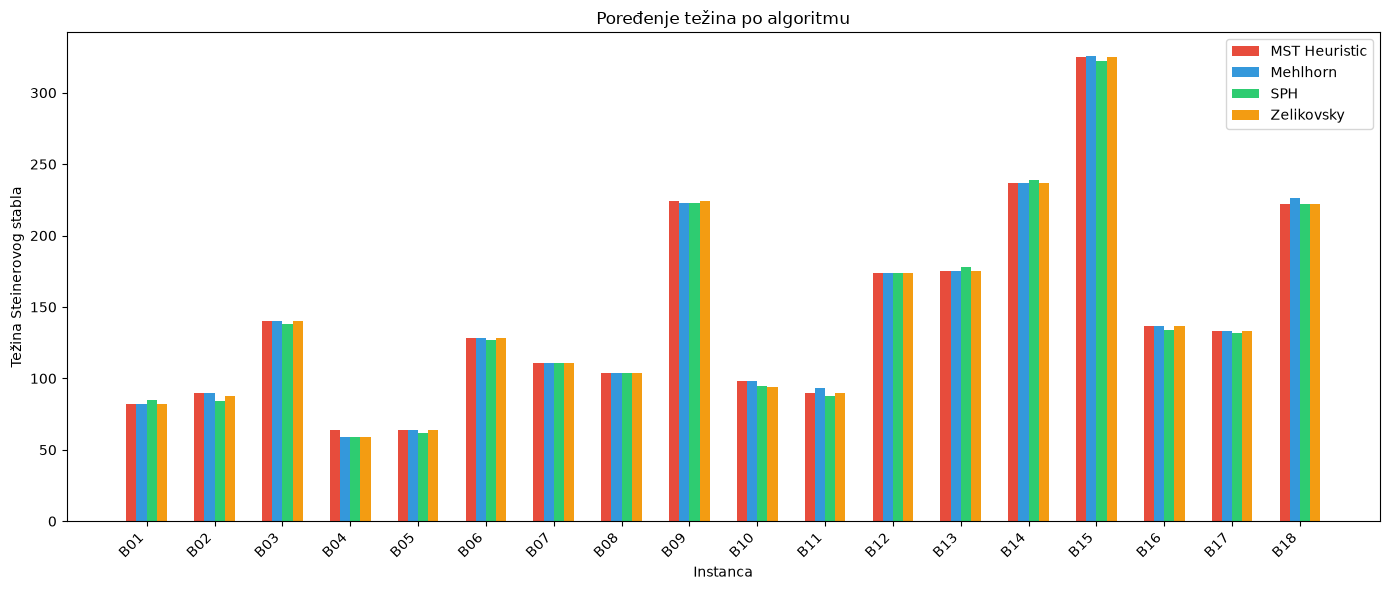

In [5]:
plot_weights(results, algorithms)

## Odstupanje od MST Heuristike

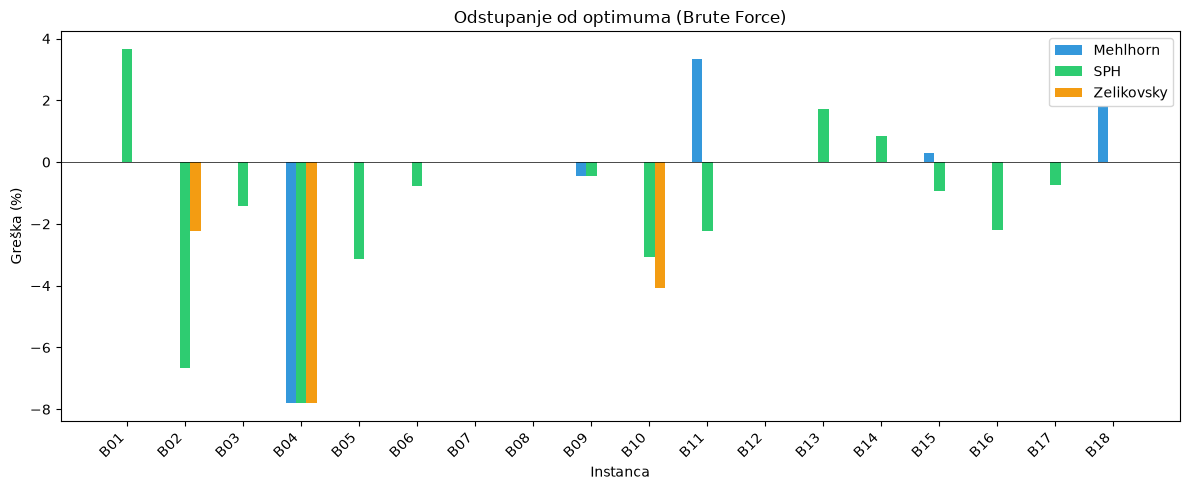

In [6]:
plot_errors(results, algorithms)

## Vreme izvršavanja

In [7]:
print_times(results, algorithms)

Instance      N    T |   MST Heur    Mehlhorn         SPH    Zelikovs
---------------------------------------------------------------------
B01          50    9 |     0.0027s     0.0010s     0.0097s     0.1921s
B02          50   13 |     0.0030s     0.0008s     0.0257s     1.3810s
B03          50   25 |     0.0125s     0.0011s     0.1784s     4.4801s
B04          50    9 |     0.0022s     0.0007s     0.0158s     0.3995s
B05          50   13 |     0.0042s     0.0010s     0.0347s     0.7244s
B06          50   25 |     0.0220s     0.0013s     0.1985s     4.9892s
B07          75   13 |     0.0045s     0.0011s     0.0489s     1.1983s
B08          75   19 |     0.0082s     0.0011s     0.0937s     3.7875s
B09          75   38 |     0.0389s     0.0016s     0.7481s    33.4342s
B10          75   13 |     0.0060s     0.0011s     0.0587s     2.5250s
B11          75   19 |     0.0123s     0.0013s     0.1133s     4.1166s
B12          75   38 |     0.0566s     0.0019s     0.9132s    39.0277s
B13     

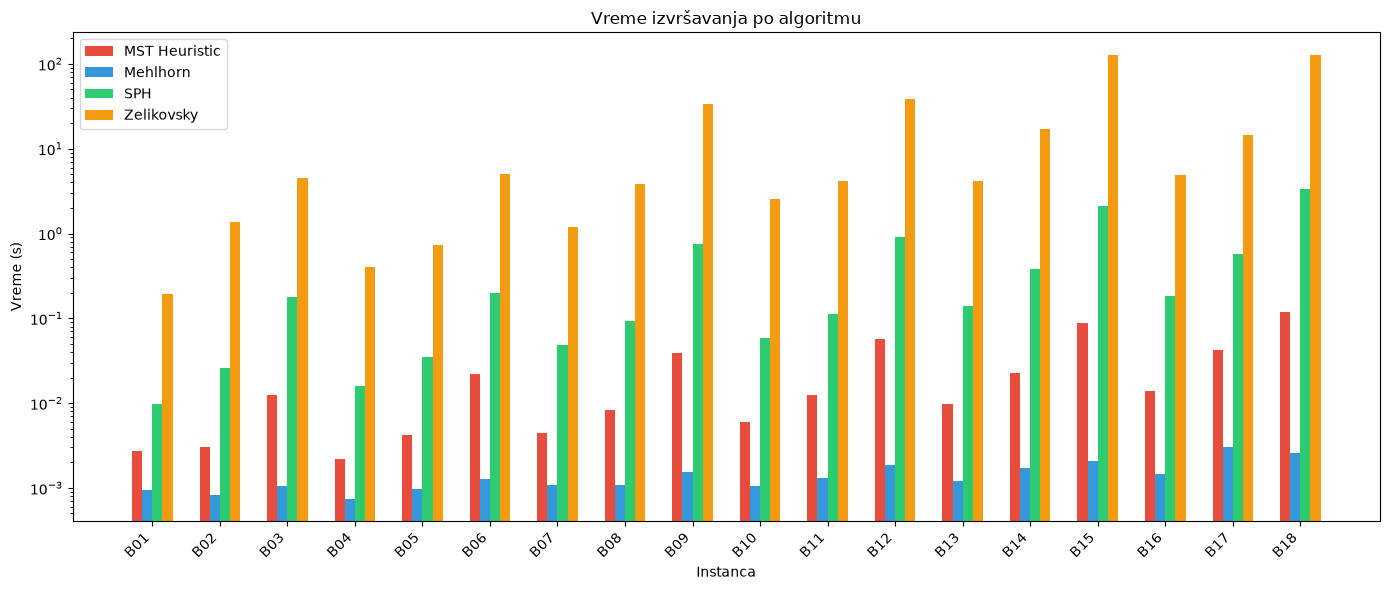

In [8]:
plot_times(results, algorithms)

## Prosečna greška po algoritmu

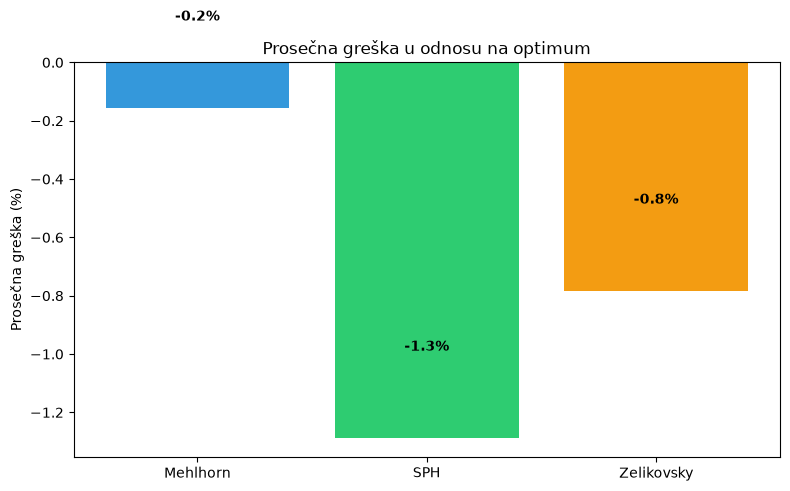

In [9]:
plot_avg_errors(results, algorithms)

## Brzina vs. kvalitet

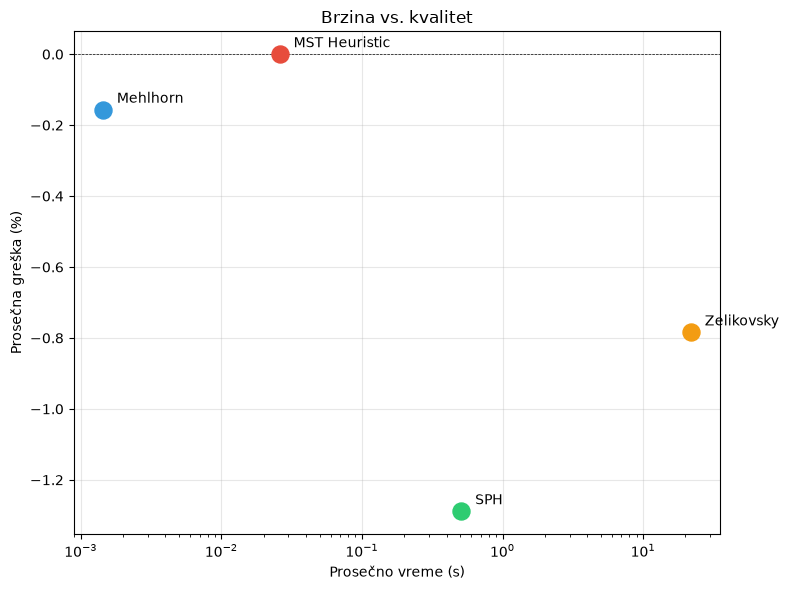

In [10]:
plot_speed_vs_quality(results, algorithms)

## Odnos težina (weight / MST Heuristic)

In [11]:
print_weight_ratios(results, algorithms)

Instance     OPT |   Mehlhorn         SPH    Zelikovs
-----------------------------------------------------
B01           82 |      1.0000      1.0366      1.0000
B02           90 |      1.0000      0.9333      0.9778
B03          140 |      1.0000      0.9857      1.0000
B04           64 |      0.9219      0.9219      0.9219
B05           64 |      1.0000      0.9688      1.0000
B06          128 |      1.0000      0.9922      1.0000
B07          111 |      1.0000      1.0000      1.0000
B08          104 |      1.0000      1.0000      1.0000
B09          224 |      0.9955      0.9955      1.0000
B10           98 |      1.0000      0.9694      0.9592
B11           90 |      1.0333      0.9778      1.0000
B12          174 |      1.0000      1.0000      1.0000
B13          175 |      1.0000      1.0171      1.0000
B14          237 |      1.0000      1.0084      1.0000
B15          325 |      1.0031      0.9908      1.0000
B16          137 |      1.0000      0.9781      1.0000
B17         

## Zelikovsky varijante (SPH i Mehlhorn baza)

In [14]:
algorithms_z = [
    ('Zelikovsky', zelikovsky_steiner, False),
    ('Zel+SPH', zelikovsky_sph, False),
    ('Zel+Mehlhorn', zelikovsky_mehlhorn, False),
]

results_z = compare_algorithms(algorithms_z, b_files)

Instance      N    T | Zeliko  Zel+SP  Zel+Me
---------------------------------------------
B01          50    9 |     82   83+1%       *
B02          50   13 |     88   83+-6%       *
B03          50   25 |    140  138+-1%       *
B04          50    9 |     59       *       *
B05          50   13 |     64   62+-3%       *
B06          50   25 |    128  127+-1%       *
B07          75   13 |    111       *       *
B08          75   19 |    104       *       *
B09          75   38 |    224  223+-0%  220+-2%
B10          75   13 |     94   93+-1%   91+-3%
B11          75   19 |     90   88+-2%   93+3%
B12          75   38 |    174       *       *
B13         100   17 |    175  178+2%       *
B14         100   25 |    237  239+1%       *
B15         100   50 |    325  322+-1%  326+0%
B16         100   17 |    137  134+-2%       *
B17         100   25 |    133  132+-1%       *
B18         100   50 |    222       *  226+2%

* = optimalno rešenje, - = preskočeno (preveliko za brute force)


## Poređenje svih 6 algoritama

In [15]:
results_all = []
for r, rz in zip(results, results_z):
    merged = dict(r)
    merged['Zel+SPH'] = rz['Zel+SPH']
    merged['Zel+SPH_time'] = rz['Zel+SPH_time']
    merged['Zel+Mehlhorn'] = rz['Zel+Mehlhorn']
    merged['Zel+Mehlhorn_time'] = rz['Zel+Mehlhorn_time']
    results_all.append(merged)

algorithms_all = [
    ('MST Heuristic', mst_heuristic, False),
    ('Mehlhorn', mehlhorn_steiner, False),
    ('SPH', sph_steiner, False),
    ('Zelikovsky', zelikovsky_steiner, False),
    ('Zel+SPH', zelikovsky_sph, False),
    ('Zel+Mehlhorn', zelikovsky_mehlhorn, False),
]

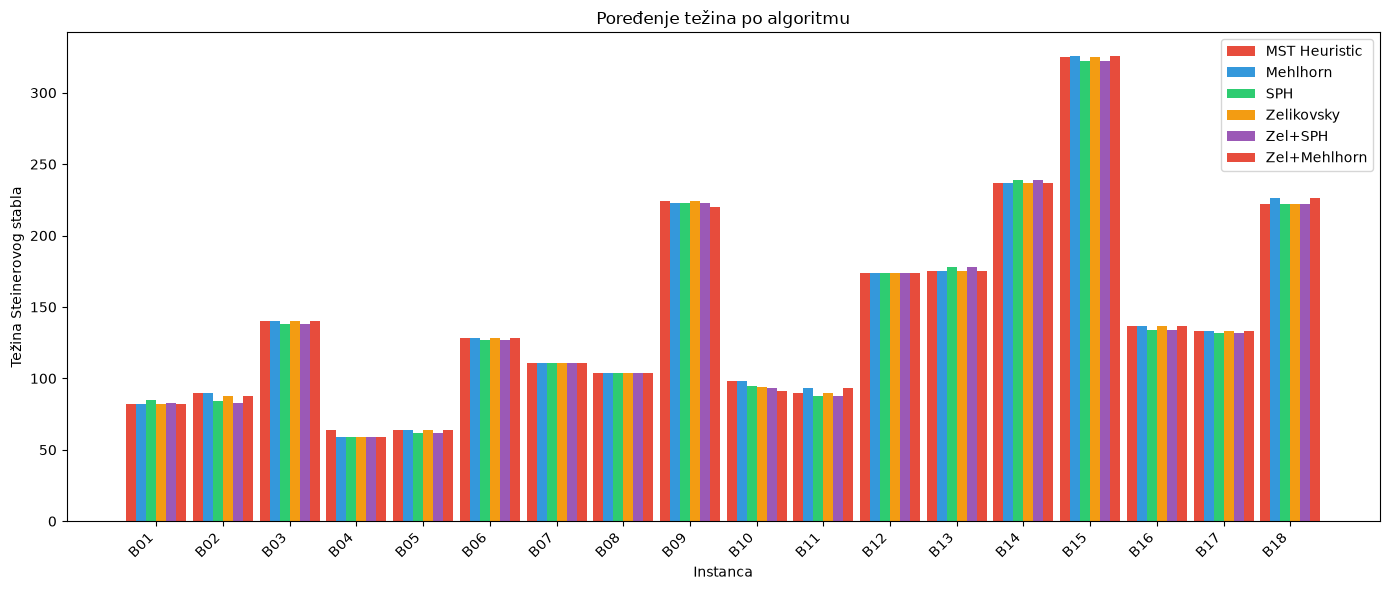

In [16]:
plot_weights(results_all, algorithms_all)

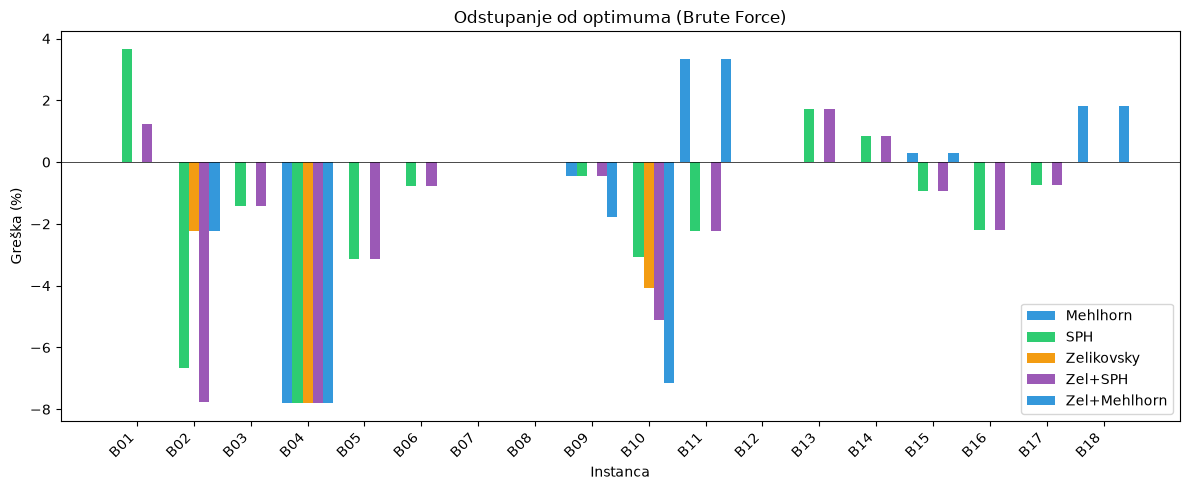

In [17]:
plot_errors(results_all, algorithms_all)

In [18]:
print_times(results_all, algorithms_all)

Instance      N    T |   MST Heur    Mehlhorn         SPH    Zelikovs     Zel+SPH    Zel+Mehl
---------------------------------------------------------------------------------------------
B01          50    9 |     0.0027s     0.0010s     0.0097s     0.1921s     0.4520s     0.1911s
B02          50   13 |     0.0030s     0.0008s     0.0257s     1.3810s     1.4950s     1.4443s
B03          50   25 |     0.0125s     0.0011s     0.1784s     4.4801s     4.3998s     4.4551s
B04          50    9 |     0.0022s     0.0007s     0.0158s     0.3995s     0.2268s     0.3350s
B05          50   13 |     0.0042s     0.0010s     0.0347s     0.7244s     0.6869s     0.7019s
B06          50   25 |     0.0220s     0.0013s     0.1985s     4.9892s     5.1816s     4.9160s
B07          75   13 |     0.0045s     0.0011s     0.0489s     1.1983s     1.2428s     1.2053s
B08          75   19 |     0.0082s     0.0011s     0.0937s     3.7875s     3.9240s     3.8699s
B09          75   38 |     0.0389s     0.0016s     0

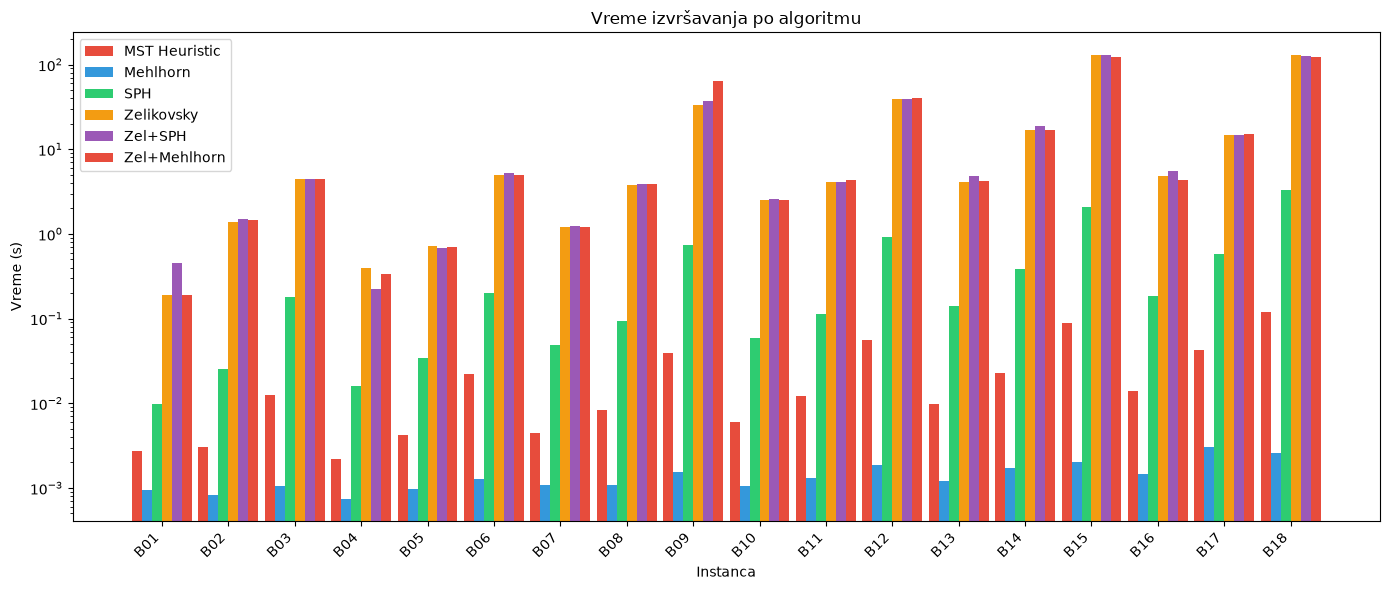

In [19]:
plot_times(results_all, algorithms_all)

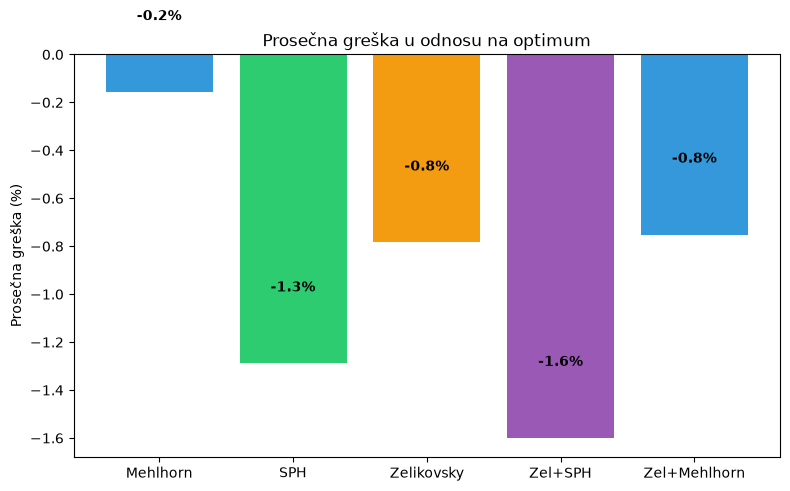

In [20]:
plot_avg_errors(results_all, algorithms_all)

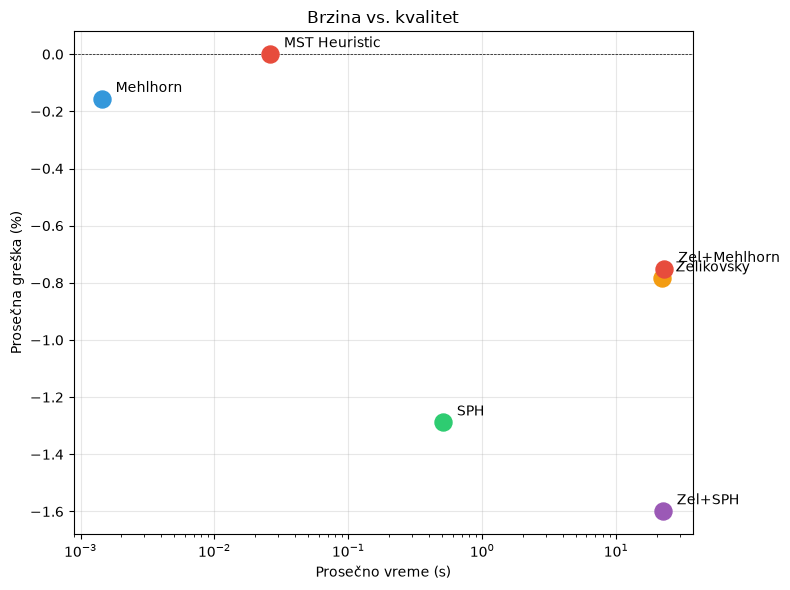

In [21]:
plot_speed_vs_quality(results_all, algorithms_all)

In [22]:
print_weight_ratios(results_all, algorithms_all)

Instance     OPT |   Mehlhorn         SPH    Zelikovs     Zel+SPH    Zel+Mehl
-----------------------------------------------------------------------------
B01           82 |      1.0000      1.0366      1.0000      1.0122      1.0000
B02           90 |      1.0000      0.9333      0.9778      0.9222      0.9778
B03          140 |      1.0000      0.9857      1.0000      0.9857      1.0000
B04           64 |      0.9219      0.9219      0.9219      0.9219      0.9219
B05           64 |      1.0000      0.9688      1.0000      0.9688      1.0000
B06          128 |      1.0000      0.9922      1.0000      0.9922      1.0000
B07          111 |      1.0000      1.0000      1.0000      1.0000      1.0000
B08          104 |      1.0000      1.0000      1.0000      1.0000      1.0000
B09          224 |      0.9955      0.9955      1.0000      0.9955      0.9821
B10           98 |      1.0000      0.9694      0.9592      0.9490      0.9286
B11           90 |      1.0333      0.9778      1.0000